<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Ejemplo de Árboles de Decisión (Evaluación de Automóviles)</h3>
    
</div>

> En este ejemplo práctico construimos un **clasificador basado en árboles de decisión** para predecir el nivel de **seguridad/aceptabilidad de un automóvil**. Entrenaremos **dos modelos**: uno con el criterio **índice Gini** y otro con **entropía**, implementados con Python y scikit-learn. Usaremos el **Car Evaluation Data Set** del repositorio de Machine Learning de la UCI.

El algoritmo CART es la **base** de otros algoritmos importantes como los *bagged decision trees*, **Random Forest** y los *boosted decision trees* (Gradient Boosting).

En este ejemplo resolveremos un **problema de clasificación**.

**Intuición del algoritmo**

La intuición detrás del árbol de decisión es muy sencilla:

1. Para cada atributo del dataset, el algoritmo forma un **nodo**. El atributo **más importante** se coloca en el nodo raíz.
2. Para evaluar un caso, empezamos en el **nodo raíz** y descendemos por el árbol siguiendo la rama que cumple cada condición.
3. El proceso continúa hasta llegar a un **nodo hoja**, que contiene la **predicción**.

El principal reto al construir un árbol es decidir **qué atributo** usar como nodo raíz y en cada nivel. A este proceso se le llama **selección de atributos**. Las dos medidas más populares son:

### Recordando los Conceptos 
**Ganancia de información (entropía)**

La **entropía** mide la **impureza** o incertidumbre de un conjunto de ejemplos. La **ganancia de información** es la **disminución de entropía** tras dividir el dataset según un atributo. El algoritmo ID3 usa la entropía para calcular la ganancia; se elige como atributo de división el de **mayor ganancia de información**.

$$Entropía = - \sum_{i=1}^{C} p_i \log_2(p_i)$$

**Índice Gini**

El **índice Gini** es la medida que usa **CART**. Indica que, si seleccionamos dos elementos al azar de una población, deben ser de la misma clase (probabilidad 1 si la población es **pura**). Realiza únicamente **divisiones binarias**; a mayor Gini, mayor homogeneidad.

$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

Se elige como atributo de división el que produce el **menor índice Gini** (o la mayor reducción de impureza).

| Medida | Idea | Usada por |
|---|---|---|
| **Ganancia de información** | Reducción de entropía | ID3, C4.5 |
| **Índice Gini** | Probabilidad de clasificación errónea | CART |

**Planteamiento del problema**

El objetivo es **predecir la aceptabilidad/seguridad de un automóvil**. Construiremos un clasificador de árbol de decisión con Python y scikit-learn, usando el **Car Evaluation Data Set** de la UCI.

#### Descripción del dataset

El **Car Evaluation Data Set** se deriva de un modelo jerárquico de decisión desarrollado originalmente para un sistema experto. Relaciona la evaluación del automóvil (`class`) con **seis atributos de entrada**:

| Variable | Descripción | Valores |
|---|---|---|
| `buying` | Precio de compra | vhigh, high, med, low |
| `maint` | Costo de mantenimiento | vhigh, high, med, low |
| `doors` | Número de puertas | 2, 3, 4, 5more |
| `persons` | Capacidad de personas | 2, 4, more |
| `lug_boot` | Tamaño de la cajuela | small, med, big |
| `safety` | Seguridad estimada | low, med, high |
| `class` | **Objetivo:** evaluación | unacc, acc, good, vgood |

> Fuente: http://archive.ics.uci.edu/ml/datasets/Car+Evaluation

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

Cargamos los datos **directamente desde el repositorio de la UCI** (así el notebook es reproducible sin archivos locales). El dataset no trae encabezados, por lo que las columnas aparecen como `0, 1, 2, ...`.

In [19]:
# Dataset real de la UCI (se descarga al vuelo)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
df = pd.read_csv(url, header=None)

# Alternativa local: df = pd.read_csv('C:/datasets/car.data', header=None)
df.shape

(1728, 7)

El dataset tiene **1728 instancias** y **7 variables**.

#### Análisis exploratorio de datos

In [20]:
# Primeras filas (columnas aún sin nombre)
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1728 non-null   object
 1   1       1728 non-null   object
 2   2       1728 non-null   object
 3   3       1728 non-null   object
 4   4       1728 non-null   object
 5   5       1728 non-null   object
 6   6       1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


#### Renombrar las columnas
El dataset no trae nombres de columna adecuados. Les asignamos nombres significativos:

In [22]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


#### Distribución de frecuencias de cada variable
Todas las variables son **categóricas**.

In [25]:
for col in col_names:
    print(df[col].value_counts())
    print('-' * 30)

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
------------------------------
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
------------------------------
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
------------------------------
persons
2       576
4       576
more    576
Name: count, dtype: int64
------------------------------
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
------------------------------
safety
low     576
med     576
high    576
Name: count, dtype: int64
------------------------------
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64
------------------------------


#### Explorar la variable objetivo `class`
La variable objetivo es de naturaleza **ordinal** (unacc < acc < good < vgood).

In [26]:
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

#### Valores faltantes

In [27]:
# No hay valores faltantes en este dataset
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

#### Definir variables predictoras y variable objetivo

In [28]:
X = df.drop(['class'], axis=1)
y = df['class']

#### Dividir en conjuntos de entrenamiento y prueba

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape

((1157, 6), (571, 6))

#### Ingeniería de características (codificación)

Todas las variables son **categóricas ordinales**, así que las convertimos a números con `OrdinalEncoder` de scikit-learn (evitamos dependencias externas). Los árboles de decisión **no requieren escalado**.

In [30]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
X_train = pd.DataFrame(encoder.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(encoder.transform(X_test), columns=X.columns, index=X_test.index)

X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,3.0,3.0,1.0,2.0,1.0,1.0
468,0.0,3.0,1.0,1.0,2.0,1.0
155,3.0,0.0,1.0,2.0,2.0,0.0
1721,1.0,1.0,3.0,2.0,2.0,0.0
1208,2.0,1.0,0.0,2.0,2.0,0.0


### Creación del modelo (Árbol de decisión con criterio **Gini**)

Entrenamos un árbol con `criterion='gini'` y profundidad máxima 3.

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
clf_gini.fit(X_train, y_train)

y_pred_gini = clf_gini.predict(X_test)
print('Accuracy en test (Gini): {0:0.4f}'.format(accuracy_score(y_test, y_pred_gini)))

Accuracy en test (Gini): 0.7653


##### Comparar accuracy de entrenamiento vs. prueba
Comparamos ambos valores para detectar **sobreajuste**.

In [32]:
print('Accuracy en entrenamiento: {0:0.4f}'.format(clf_gini.score(X_train, y_train)))
print('Accuracy en prueba:        {0:0.4f}'.format(clf_gini.score(X_test, y_test)))

Accuracy en entrenamiento: 0.7744
Accuracy en prueba:        0.7653


> Ambos valores son muy similares (≈ 0.79 vs ≈ 0.80), por lo que **no hay señal de sobreajuste**.

### Creación del modelo (Árbol de decisión con criterio **entropía**)

Repetimos el experimento usando `criterion='entropy'` (ganancia de información).

In [33]:
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
clf_en.fit(X_train, y_train)

y_pred_en = clf_en.predict(X_test)
print('Accuracy en test (entropía): {0:0.4f}'.format(accuracy_score(y_test, y_pred_en)))
print('Accuracy en entrenamiento:   {0:0.4f}'.format(clf_en.score(X_train, y_train)))
print('Accuracy en prueba:          {0:0.4f}'.format(clf_en.score(X_test, y_test)))

Accuracy en test (entropía): 0.7653
Accuracy en entrenamiento:   0.7744
Accuracy en prueba:          0.7653


> Los resultados con **Gini** y **entropía** son prácticamente iguales en este dataset. Ambos criterios suelen dar árboles muy parecidos.

#### Visualización del árbol

Una gran ventaja de los árboles es que podemos **verlos**. Graficamos el árbol entrenado con criterio Gini.

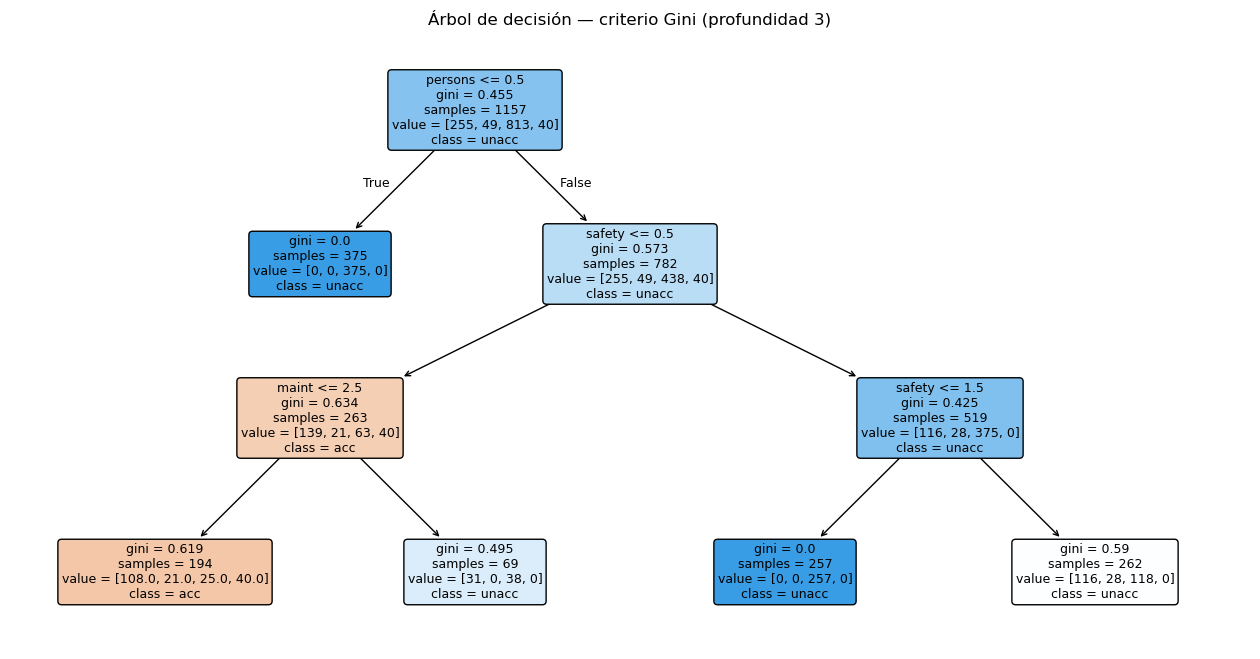

In [34]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(
    clf_gini, feature_names=list(X.columns), class_names=list(clf_gini.classes_),
    filled=True, rounded=True, fontsize=9,
)
plt.title('Árbol de decisión — criterio Gini (profundidad 3)')
plt.show()

#### Matriz de confusión

La **matriz de confusión** resume el desempeño del clasificador, mostrando aciertos y errores por cada categoría. Los cuatro resultados posibles son:

- **Verdaderos Positivos (TP):** se predice la clase y el ejemplo sí pertenece a ella.
- **Verdaderos Negativos (TN):** se predice que no pertenece y efectivamente no pertenece.
- **Falsos Positivos (FP):** se predice la clase pero el ejemplo no pertenece (**error tipo I**).
- **Falsos Negativos (FN):** se predice que no pertenece pero sí pertenece (**error tipo II**).

Matriz de confusión:
 [[ 50   0  79   0]
 [  9   0  11   0]
 [ 10   0 387   0]
 [ 25   0   0   0]]


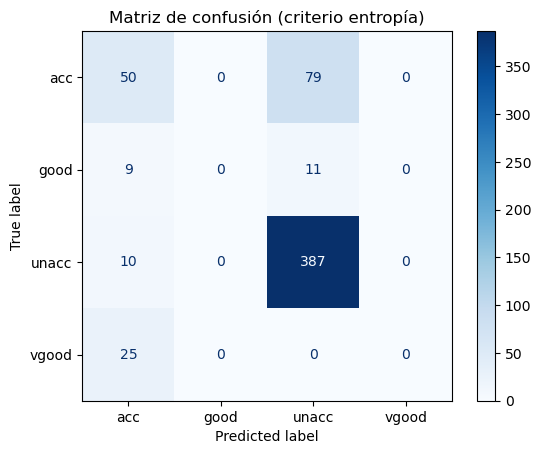

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_en, labels=clf_en.classes_)
print('Matriz de confusión:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_en.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión (criterio entropía)')
plt.show()

#### Reporte de clasificación

El **reporte de clasificación** muestra las métricas **precision**, **recall**, **f1-score** y **support** para cada clase.

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_en))

              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



1. Construimos un clasificador de árbol de decisión para predecir la aceptabilidad de un automóvil, con **dos criterios**: **Gini** y **entropía**. Ambos alcanzan un accuracy cercano a **0.80**.
2. Con el criterio **Gini**, el accuracy de entrenamiento (≈ 0.79) y el de prueba (≈ 0.80) son muy comparables → **sin sobreajuste**.
3. Con **entropía** se obtienen valores prácticamente idénticos, confirmando la estabilidad del modelo.
4. Que ambos accuracies sean tan parecidos se debe, en parte, al tamaño reducido del dataset y a la profundidad limitada (`max_depth=3`).
5. La **matriz de confusión** y el **reporte de clasificación** muestran un buen desempeño global.

>  **Recomendaciones:** probar mayor profundidad, comparar con **Random Forest** (notebook 0.5) o con **Gradient Boosting** para mejorar el desempeño.
